In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

100%|██████████| 5000/5000 [00:03<00:00, 1411.53it/s]


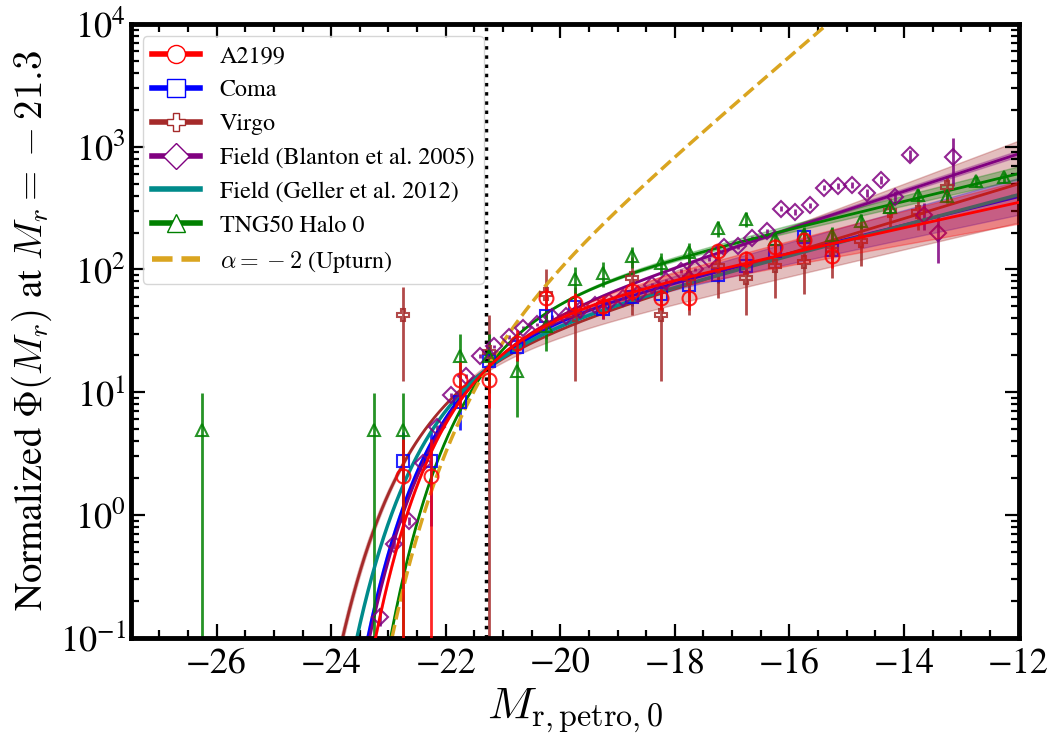

In [2]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --------------------------------------------------------------------
# Load all luminosity function data into a dictionary
# --------------------------------------------------------------------
df_dict = {
    'A2199': pd.read_csv('A2199_LF.csv'),
    'Coma': pd.read_csv('Coma_LF.csv'),
    'TNG50 Halo 0': pd.read_csv('TNG50_Halo0_LF.csv'),
    'Field': pd.read_csv('Field_LF.csv'),
    'Virgo': pd.read_csv('Virgo_LF.csv')
}

# --------------------------------------------------------------------
# Define Schechter function for fitting
# --------------------------------------------------------------------
def schechter_1D_LF(M, phi_0, M_star, alpha):
    """
    Compute Schechter function at given M values.
    """
    exponent = 10 ** (0.4 * (M_star - M))
    return phi_0 * exponent ** (1 + alpha) * np.exp(-exponent)

# --------------------------------------------------------------------
# MCMC support: log-likelihood, prior, and probability functions
# --------------------------------------------------------------------
def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))  # Gaussian likelihood

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1000 and -25 < M_star < -15 and -3.5 < alpha < 0.5:
        return 0.0  # flat prior
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# --------------------------------------------------------------------
# Perform MCMC fit of Schechter function to data
# --------------------------------------------------------------------
def fit_schechter_mcmc(x, y, yerr, nwalkers=50, nsteps=5000):
    ndim = 3
    initial = np.array([1.0, -20.0, -1.0])  # initial guess: [phi_0, M_star, alpha]
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
    sampler.run_mcmc(pos, nsteps, progress=True)
    samples = sampler.get_chain(discard=1000, thin=15, flat=True)
    phi_0 = np.percentile(samples[:, 0], [16, 50, 84])
    M_star = np.percentile(samples[:, 1], [16, 50, 84])
    alpha = np.percentile(samples[:, 2], [16, 50, 84])
    return (phi_0, M_star, alpha), samples

# --------------------------------------------------------------------
# Simple Y scaling factors to visually separate/scale the curves
# --------------------------------------------------------------------
y_shifts = {
    'A2199': 5.0,
    'Coma': 1.0 * 1.05 * 1.5,
    'TNG50 Halo 0': 10.0 * 1.3,
    'Field': 2000.0 * 1.03 * 2,
    'Virgo': 1.0 * 1.4125,
}

# --------------------------------------------------------------------
# Fit Schechter function for each sample, record results and models
# --------------------------------------------------------------------
fit_results = {}
x_model = np.linspace(-27.5, 0, 8000)  # dense grid for plotting models

for label, df in df_dict.items():
    x = df['M_r'].values
    y = df['Phi'].values * y_shifts[label]
    yerr = df['Phi_err'].values * y_shifts[label]
    (phi0_vals, mstar_vals, alpha_vals), _ = fit_schechter_mcmc(x, y, yerr)
    phi_0_med = phi0_vals[1]
    M_star_med = mstar_vals[1]
    alpha_med = alpha_vals[1]
    y_model = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_med)
    y_model_lo = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_vals[0])
    y_model_hi = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_vals[2])
    fit_results[label] = {
        'x': x,
        'y': y,
        'yerr': yerr,
        'phi0': phi0_vals,
        'Mstar': mstar_vals,
        'alpha': alpha_vals,
        'y_model': y_model,
        'y_model_lo': y_model_lo,
        'y_model_hi': y_model_hi
    }

# --------------------------------------------------------------------
# Plotting styles for each sample
# --------------------------------------------------------------------
colors = {
    'A2199': 'red',
    'Coma': 'blue',
    'TNG50 Halo 0': 'green',
    'Field': 'purple',
    'Virgo': 'brown'
}
markers = {
    'A2199': 'o',
    'Coma': 's',
    'TNG50 Halo 0': '^',
    'Field': 'D',
    'Virgo': 'P'
}
# The order of plotting (A2199 plotted last for highlight)
plot_order = ['Coma', 'Virgo', 'Field', 'TNG50 Halo 0']

# --------------------------------------------------------------------
# Start plotting normalized luminosity functions
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8))

x_norm = -21.30  # x-value for normalization (vertical line)
y_norm_target = np.interp(x_norm, x_model, fit_results['A2199']['y_model'])  # A2199 at norm

# Plot all but A2199, normalized at x_norm to match A2199 value
for label in plot_order:
    result = fit_results[label]
    y_at_norm = np.interp(x_norm, x_model, result['y_model'])
    scale_factor = y_norm_target / y_at_norm if y_at_norm > 0 else 1.0
    y_scaled = result['y'] * scale_factor
    yerr_scaled = result['yerr'] * scale_factor
    y_model_scaled = result['y_model'] * scale_factor
    y_model_lo_scaled = result['y_model_lo'] * scale_factor
    y_model_hi_scaled = result['y_model_hi'] * scale_factor
    # Plot normalized fit with uncertainty
    ax.plot(x_model, y_model_scaled, linestyle='-', lw=2, color=colors[label])
    ax.fill_between(x_model, y_model_lo_scaled, y_model_hi_scaled, color=colors[label], alpha=0.3)
    # Plot data points with error bars
    ax.errorbar(result['x'], y_scaled, yerr=yerr_scaled, fmt=markers[label], color=colors[label],
                markerfacecolor='none', markeredgewidth=1.5, capsize=0, alpha=0.85, markersize=8)

# --------------------------------------------------------------------
# Plot reference Schechter curves, normalized at same point
# --------------------------------------------------------------------
# Reference 1: alpha=-2 upturn line
y_ref_unscaled = schechter_1D_LF(x_model, 36.0, -21.3, -2.0)
y_ref_at_norm = np.interp(x_norm, x_model, y_ref_unscaled)
ref_scale_factor = y_norm_target / y_ref_at_norm
ax.plot(x_model, y_ref_unscaled * ref_scale_factor, ls='--', color='goldenrod', lw=2.5)

# Reference 2: Geller et al. 2012 fit
y_geller_unscaled = schechter_1D_LF(x_model, 140, -21.80, -1.31)
y_geller_at_norm = np.interp(x_norm, x_model, y_geller_unscaled)
geller_scale_factor = y_norm_target / y_geller_at_norm
ax.plot(x_model, y_geller_unscaled * geller_scale_factor, ls='-', color='darkcyan', lw=2.5)

# --------------------------------------------------------------------
# Plot A2199 last, highlighted (on top)
# --------------------------------------------------------------------
result = fit_results['A2199']
ax.plot(x_model, result['y_model'], linestyle='-', lw=2, color=colors['A2199'], zorder=10)
ax.fill_between(x_model, result['y_model_lo'], result['y_model_hi'], color=colors['A2199'], alpha=0.3, zorder=10)
ax.errorbar(result['x'], result['y'], yerr=result['yerr'], fmt=markers['A2199'], color=colors['A2199'],
            markerfacecolor='none', markeredgewidth=1.5, capsize=0, alpha=0.85, markersize=10, zorder=10)

# --------------------------------------------------------------------
# Axis limits, labels, ticks, vertical normalization line
# --------------------------------------------------------------------
ax.set_yscale('log')
ax.set_xlim(-27.5, -12)
ax.set_ylim(0.1, 10000)
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=33)
ax.set_ylabel(r'Normalized $\Phi(M_r)$ at $M_r = -21.3$', fontsize=28)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=26)
ax.axvline(x_norm, color='black', linestyle=':', lw=2.5) # Normalization point

# --------------------------------------------------------------------
# Custom legend handles and labels
# --------------------------------------------------------------------
custom_lines = [
    Line2D([0], [0], color=colors['A2199'], marker=markers['A2199'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Coma'], marker=markers['Coma'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Virgo'], marker=markers['Virgo'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Field'], marker=markers['Field'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color='darkcyan', linestyle='-', linewidth=4),
    Line2D([0], [0], color=colors['TNG50 Halo 0'], marker=markers['TNG50 Halo 0'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color='goldenrod', linestyle='--', linewidth=4)
]
legend_labels = [
    'A2199',
    'Coma',
    'Virgo',
    'Field (Blanton et al. 2005)',
    'Field (Geller et al. 2012)',
    'TNG50 Halo 0',
    r'$\alpha = -2$ (Upturn)'
]
ax.legend(custom_lines, legend_labels, loc='upper left', fontsize=17.3)

plt.tight_layout()
# plt.savefig('/Users/jonginpark/A2199_LF/FIGURE/images/LF_normalized_comparison.pdf', bbox_inches='tight', dpi=1500)
plt.show()

In [3]:
import pandas as pd

# --- Build df_all from fit_results ---
records = []

for sample_name, result in fit_results.items():
    x_vals = result['x']
    y_vals = result['y']
    yerr_vals = result['yerr']
    
    for x, y, yerr in zip(x_vals, y_vals, yerr_vals):
        records.append({
            'Sample': sample_name,
            'M_r': x,
            'Phi': y,
            'Phi_err': yerr
        })

df_all = pd.DataFrame(records)

# --- HEADER TEXT (UPDATED FORMATS & ORDERED SAMPLE-ID MAPPING) ---
header_txt = """
Title: A redshift survey of the nearby galaxy cluster Abell 2199 : No
upturn of the faint-end slope of galaxy luminosity function

Authors: Park J., Song H., Hwang H.S.
Table: Normalized Luminosity Function of A2199 and other samples

================================================================================
Byte-by-byte Description of file: v57n2p249_Table3.txt
--------------------------------------------------------------------------------
  Bytes  Format    Units             Label      Explanations
--------------------------------------------------------------------------------
   1-  1  I1       ---               Sample     Sample ID (1)
   3-  8  F6.2     mag               M_r        Absolute magnitude (2)
  10 -14  F5.1     h3Mpc-3mag-1      Phi        Luminosity function value (3)
  16- 20  F5.1     h3Mpc-3mag-1      Phi_err    Uncertainty in Phi (4)
--------------------------------------------------------------------------------
Note (1):
    Sample ID mapping:
      1 = A2199 (This study)
      2 = Coma (Kang et al. 2025) [2025ApJS..278...51K]
      3 = Virgo (Ferrarese et al. 2020) [2020ApJ...890..128F]
      4 = Field (Blanton et al. 2005) [2005ApJ...631..208B]
      5 = TNG50 Halo 0 (This study)

Note (2):
    Absolute magnitude is calculated based on the LambdaCDM cosmology
    with H0 = 70 km/s/Mpc, Omega_m = 0.3, and Omega_Lambda = 0.7.

Note (3):
    Phi and Phi_err are in comoving number density units: [h³ Mpc⁻³ mag⁻¹]
    Phi values are normalized to the luminosity function of A2199 at M_r = -21.3, which is the characteristic magnitude of the Schechter fit. While the other cluster luminosity functions are not in absolute units, they are scaled accordingly for comparison.

Note (4):
    Uncertainties in Phi are estimated from the Poisson statistics.
--------------------------------------------------------------------------------
"""

# --- Desired explicit Sample-ID order ---
# Ensures: 1=A2199, 2=Coma, 3=Virgo, 4=Field, 5=TNG50 Halo 0
desired_order = ["A2199", "Coma", "Virgo", "Field", "TNG50 Halo 0"]

# --- Build Sample-ID mapping using desired order ---
# If a desired sample is missing from df_all, it will still be in the mapping but unused.
# If df_all contains an unexpected sample, it will be appended after the desired ones in a stable manner.
present_labels = list(pd.unique(df_all['Sample']))

# Keep desired ones in order, then add any extras not in desired_order (stable)
ordered_labels = [s for s in desired_order if s in present_labels] + \
                 [s for s in present_labels if s not in desired_order]

sample_mapping = {name: i + 1 for i, name in enumerate(ordered_labels)}

# --- Save to file ---
output_path = '../../DATA/A2199_Machine_Redable_Table3.txt'

# Determine max widths (based on new formats)
m_r_width = max(df_all['M_r'].apply(lambda x: f"{x:.2f}").map(len))
phi_width = max(df_all['Phi'].apply(lambda x: f"{x:.1f}").map(len))
phierr_width = max(df_all['Phi_err'].apply(lambda x: f"{x:.1f}").map(len))

with open(output_path, 'w') as f:
    f.write(header_txt.strip() + '\n\n')
    
    for _, row in df_all.iterrows():
        sample_id = sample_mapping[row['Sample']]
        m_r_str = f"{row['M_r']:.2f}".rjust(m_r_width)
        phi_str = f"{row['Phi']:.1f}".rjust(phi_width)
        phierr_str = f"{row['Phi_err']:.1f}".rjust(phierr_width)

        f.write(f"{sample_id:1d} {m_r_str} {phi_str} {phierr_str}\n")

# --- Print Sample-to-ID Mapping ---
print("Sample-to-ID Mapping:")
for name in ordered_labels:
    print(f"  {sample_mapping[name]} = {name}")

Sample-to-ID Mapping:
  1 = A2199
  2 = Coma
  3 = Virgo
  4 = Field
  5 = TNG50 Halo 0


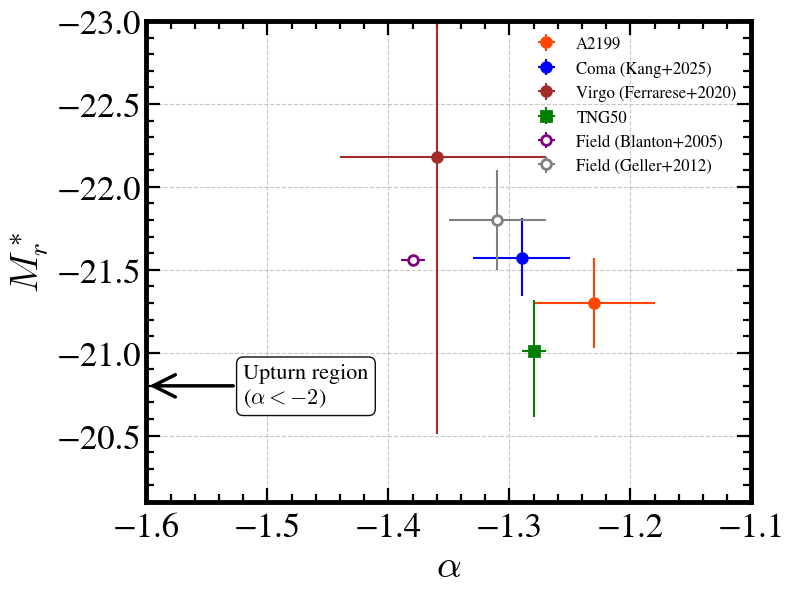

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Manually extracted data from the table
fit_data = [
    {'label': 'A2199', 'alpha': -1.23, 'alpha_err': [0.05, 0.05], 'M_star': -21.30, 'M_star_err': [0.27, 0.27]},
    {'label': 'Coma (Kang+2025)', 'alpha': -1.29, 'alpha_err': [0.04, 0.04], 'M_star': -21.57, 'M_star_err': [0.24, 0.23]},
    {'label': 'Virgo (Ferrarese+2020)', 'alpha': -1.36, 'alpha_err': [0.08, 0.09], 'M_star': -22.18, 'M_star_err': [2.16, 1.67]},
    {'label': 'TNG50', 'alpha': -1.28, 'alpha_err': [0.01, 0.01], 'M_star': -21.01, 'M_star_err': [0.31, 0.40]},
    {'label': 'Field (Blanton+2005)', 'alpha': -1.38, 'alpha_err': [0.01, 0.01], 'M_star': -21.56, 'M_star_err': [0.01, 0.01]},
    {'label': 'Field (Geller+2012)', 'alpha': -1.31, 'alpha_err': [0.04, 0.04], 'M_star': -21.80, 'M_star_err': [0.30, 0.30]},
]

# Custom style for each label
custom_styles = {
    'A2199':                     {'marker': 'o', 'color': 'orangered', 'fill': True},
    'Coma (Kang+2025)':         {'marker': 'o', 'color': 'blue', 'fill': True},
    'Virgo (Ferrarese+2020)':   {'marker': 'o', 'color': 'brown', 'fill': True},
    'TNG50':                    {'marker': 's', 'color': 'green', 'fill': True},
    'Field (Blanton+2005)':     {'marker': 'o', 'color': 'purple', 'fill': False},
    'Field (Geller+2012)':      {'marker': 'o', 'color': 'gray', 'fill': False},
}

# Create figure
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# Plot each data point with error bars
for result in fit_data:
    label = result['label']
    alpha = result['alpha']
    alpha_err = result['alpha_err']
    mstar = result['M_star']
    mstar_err = result['M_star_err']
    style = custom_styles[label]

    ax.errorbar(alpha, mstar,
                xerr=[[alpha_err[0]], [alpha_err[1]]],
                yerr=[[mstar_err[0]], [mstar_err[1]]],
                fmt=style['marker'],
                color=style['color'],
                markersize=7,
                markerfacecolor=style['color'] if style['fill'] else 'white',
                markeredgecolor=style['color'],
                markeredgewidth=2,
                lw=1.5,
                capsize=0,
                label=label)

# Annotation
ax.annotate(r'Upturn region' + '\n' + r'($\alpha < -2$)',
            xy=(-1.6, -20.8), xytext=(-1.52, -20.8),
            fontsize=16, ha='left', va='center',
            arrowprops=dict(arrowstyle="->", color='black', mutation_scale=40, linewidth=2.5),
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.95),
            color='black')

# Axes formatting
ax.set_xlabel(r'$\alpha$', fontsize=28)
ax.set_ylabel(r'$M^*_r$', fontsize=28)
ax.set_xlim(-1.6, -1.1)
ax.set_ylim(-23, -20.1)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()
